<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="../Images/Xlogo.png" alt="logo" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong> APM_52448_EP - Deep Learning in Finance   </strong></p>
    <p style=" text-align: center; font-size: 30px;"> 
    <strong> Tutorial 4:  Portfolio Optimization </strong> </p>
  <p style=" text-align: left; font-size: 20px;"> Olivier Féron </p>
</header>

# Objectives

In this tutorial we revisit classical *mean-variance* portfolio optimization and show how to **learn** the efficient frontier with a neural network.

By the end you should be able to:

- compute daily and annualized returns/covariances from a multi-asset dataset;
- compute an efficient frontier (long-only) using numerical optimization;
- train a small NN to approximate the mapping `target return -> optimal weights`;
- compare the NN frontier to the Markowitz frontier and discuss limitations.

**Dataset**: a consolidated CSV of 7 assets (Air Liquide, Microsoft, Apple, Sanofi, LVMH, S&P 500, CAC 40).
(The notebook assumes a local file; adapt the path if needed.)

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple, List, Dict

from scipy.optimize import minimize

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from time import perf_counter
import joblib
# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## 1. Data loading

In [2]:
# Path of your consolidated dataset
# (Update if your folder structure differs)
fichier = '../Data/HistoricalData7assets.csv'

df = pd.read_csv(fichier, sep=';')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date').dropna(how='all')

price = df.set_index('Date')
price.head()

,AirLiquide,Microsoft,Apple,Sanofi,LVMH,SP500,CAC40
Date,,,,,,,
2015-01-02,67.46,46.76,27.33,75.05,130.85,2058.2,4252.29
2015-01-05,65.37,46.33,26.56,72.89,127.05,2020.6,4111.36
2015-01-06,64.82,45.65,26.57,73.13,125.60,2002.6,4083.50
2015-01-07,65.12,46.23,26.94,73.90,125.70,2025.9,4112.73
2015-01-08,67.86,47.59,27.97,77.02,129.65,2062.1,4260.19


We will work only on stock prices (eliminating, for the moment, indices)

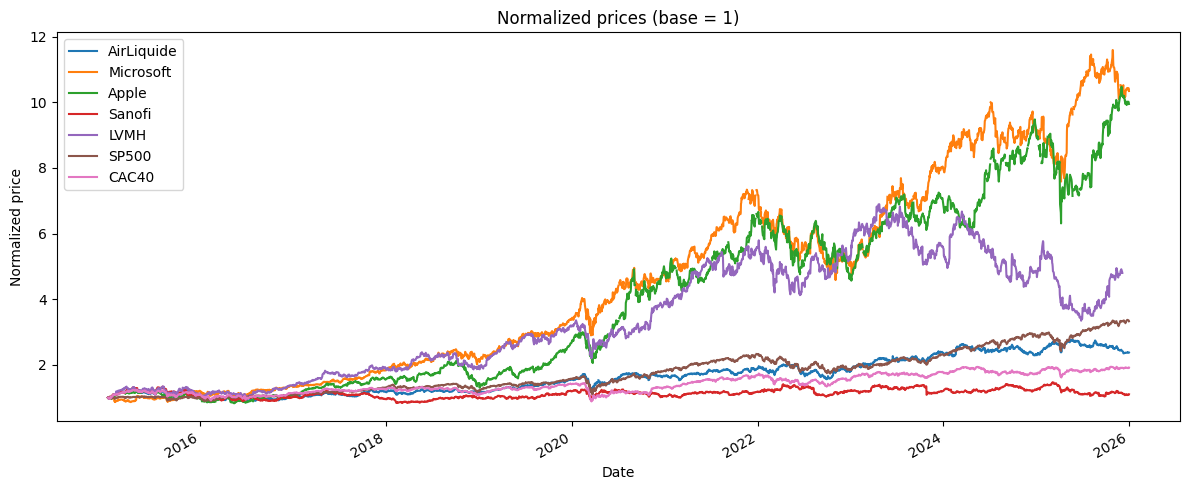

In [3]:
# Quick visual check: normalized prices (base = 1)
price_norm = price / price.iloc[0]
ax = price_norm.plot(figsize=(12,5))
ax.set_title('Normalized prices (base = 1)')
ax.set_xlabel('Date'); ax.set_ylabel('Normalized price')
plt.tight_layout()

## 2. Returns, mean and covariance

We will work only on stock prices (eliminating, for the moment, indices)

<span style="color: red;">**2.1** Compute annualized mean return and volatility of each asset  </span>


In [12]:
price = price.iloc[:,:5]

ret = price.pct_change().dropna().mean() * 252

vol = price.pct_change().dropna().std() * np.sqrt(252)

values_df = pd.DataFrame({
    'Asset': price.columns,
    'Annualized Returns': ret.values,
    'Annualized Volatility': vol.values
})
print(values_df)

        Asset  Annualized Returns  Annualized Volatility
0  AirLiquide            0.128899               0.202086
1   Microsoft            0.240779               0.269883
2       Apple            0.257846               0.288715
3      Sanofi            0.033949               0.225541
4        LVMH            0.202479               0.286011


<span style="color: red;">**2.2** Compute correlation of assets  </span>

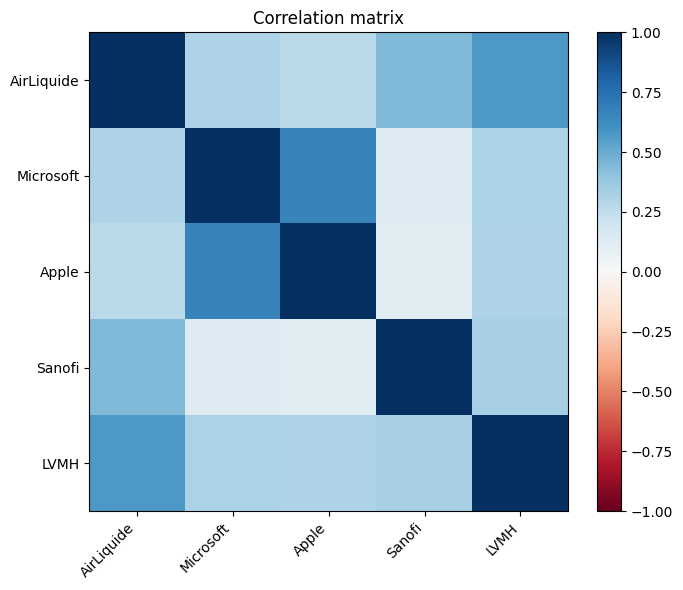

            AirLiquide  Microsoft     Apple    Sanofi      LVMH
AirLiquide    1.000000   0.308703  0.272949  0.439031  0.571467
Microsoft     0.308703   1.000000  0.667415  0.132173  0.319290
Apple         0.272949   0.667415  1.000000  0.123356  0.311140
Sanofi        0.439031   0.132173  0.123356  1.000000  0.332689
LVMH          0.571467   0.319290  0.311140  0.332689  1.000000


In [18]:
# Correlation heatmap
corr = price.pct_change().dropna().corr()

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, interpolation="none", cmap="RdBu")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()
print(corr)

## 3. Markowitz efficient frontier 

### 3.1 Analytical solution $\alpha(\lambda)$

In this section, we consider the classical Markowitz problem without any constraints on the weights (other than the self-financing constraints. 

We solve the Markowitz problem in a regularized form: for a fixed $\lambda$  we then seek the solution of the following problem:
$$
\max_{\alpha} = 
\alpha^\top \mu - \frac{\lambda}{2}\alpha^\top \Sigma \alpha  \\
 	\text{s.t.:} \qquad  
   \sum_i \alpha_i = 1, \\
$$

<span style="color: red;">**3.1** Proove that the solution of the Markowitz problem above is given by: 
:
$$
\hat \alpha(\lambda) = \frac{1}{\lambda} \Sigma^{-1} \left(\mu + \frac{\lambda - \mathbf{1}^\top \Sigma^{-1}\mu}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}} \mathbf{1} \right)
$$
 </span>

<span style="color: red;">**3.2** Implement the function `solve_markowitz_lambda` the gives the solution $\hat \alpha(\lambda)$  </span>

In [ ]:
def solve_markowitz_lambda(mu, Sigma, lam):
    inv_Sigma = np.linalg.inv(Sigma)
    ones = np.ones(len(mu))
    A = ones.T @ inv_Sigma @ ones
    B = ones.T @ inv_Sigma @ mu
    alpha = 1 / lam * inv_Sigma @ (mu + (lam - B) / A * ones)

    return alpha


mu = price.pct_change().dropna().mean() * 252
Sigma = price.pct_change().dropna().cov() * 252
lam = 1

alpha_hat = solve_markowitz_lambda(mu, Sigma, lam)
print(alpha_hat)

# Sanity check
print(np.sum(alpha_hat))

[-0.10371256  0.94402087  1.1284174  -2.14747817  1.17875246]
1.0000000000000004


### 3.2 Efficient Pareto frontier 

By making $\lambda$ vary, one can retrieve the efficient curve 

<p align="center"><img src="../Images/EfficientFrontier.png" alt="logo" width="300"></p> 

<br> 

<span style="color: red;"> **3.3** Implement the function `build_efficient_frontier` that computes the efficient frontier $\hat \alpha(\lambda)$ for $\lambda$ in a grid</span>

<span style="color: red;"> **3.4** Compute and plot the efficient frontier correponding to the estimated $\mu$ and $\Sigma$ and plot it</span>

<span style="color: red;"> **3.5** Plot the wieghts $\alpha^i(\lambda)$ of each asset in function of $\lambda$</span>

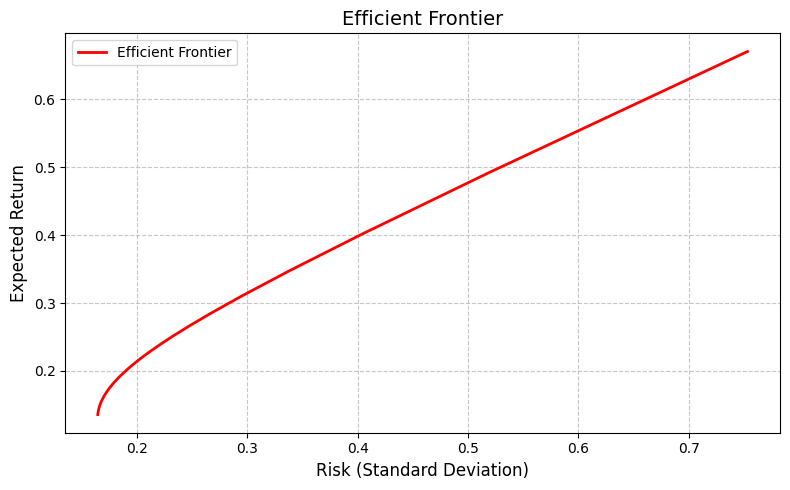

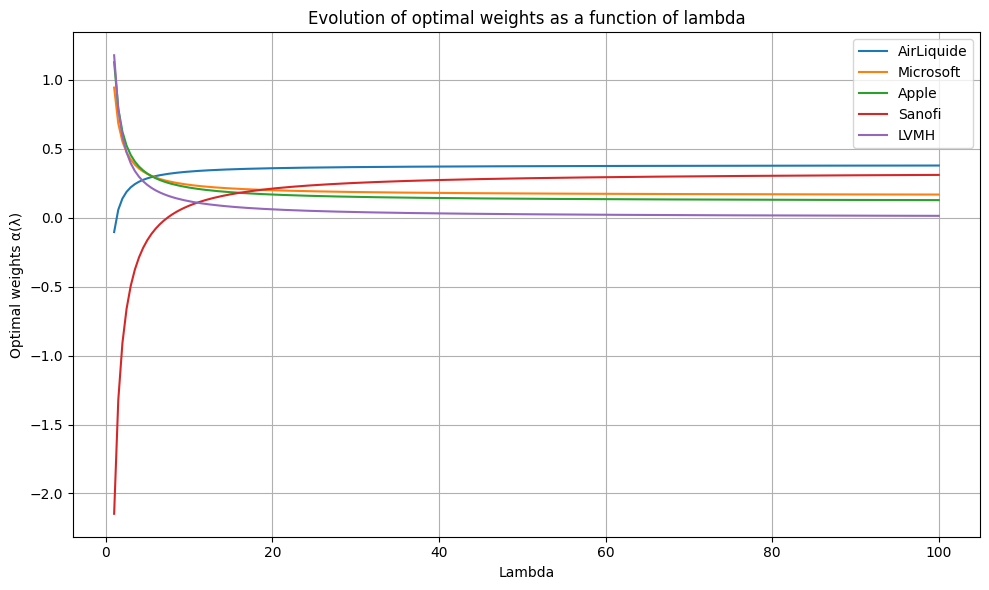

In [23]:
def build_frontier(mu, Sigma, lambda_min=1, lambda_max=100, n_points=200):
    """
    Build the efficient frontier.

    Returns:
        risks      : portfolio standard deviations
        returns    : portfolio expected returns
        weights    : list of optimal portfolios
        lambdas    : grid of lambda values
    """

    lambda_grid = np.linspace(lambda_min, lambda_max, n_points)
    risks = []
    returns = []
    alpha_hat_list = []
    
    for lam in lambda_grid:
        alpha_hat = solve_markowitz_lambda(mu, Sigma, lam)
        
        port_return = alpha_hat @ mu
        port_risk = np.sqrt(alpha_hat.T @ Sigma @ alpha_hat)
        
        alpha_hat_list.append(alpha_hat)
        returns.append(port_return)
        risks.append(port_risk)
    
    return np.array(risks), np.array(returns), np.array(alpha_hat_list), lambda_grid
    
lambda_min = 1
lambda_max = 100

risks, returns, alpha_hat, lambda_grid = build_frontier(mu, Sigma, lambda_min=lambda_min, lambda_max=lambda_max, n_points=200)

plt.figure(figsize=(8,5))
plt.plot(risks, returns, color='red', linewidth=2, label="Efficient Frontier")
plt.title("Efficient Frontier", fontsize=14)
plt.xlabel("Risk (Standard Deviation)", fontsize=12)
plt.ylabel("Expected Return", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


alpha_mat = np.array(alpha_hat)   # shape (n_points, n_assets)

plt.figure(figsize=(10,6))

asset_names = price.columns     
n_assets = alpha_mat.shape[1]
for i in range(n_assets):
    plt.plot(lambda_grid, alpha_mat[:, i], label=asset_names[i])

plt.xlabel("Lambda")
plt.ylabel("Optimal weights α(λ)")
plt.title("Evolution of optimal weights as a function of lambda")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.3 The case "long only"

In this section, we consider the Markowitz problem with constraints on the weights such that selling is not possible. 

We solve the Markowitz problem in a regularized form: for a fixed $\lambda$  we then seek the solution of the following problem:
$$
\max_{\alpha} =  \alpha^\top \mu \;-\; \frac{\lambda}{2}\,\alpha^\top \Sigma \alpha \\
\text{s.t.:} 
\begin{array}{ll}
\sum\limits_i \alpha_i = 1, \\[6pt]
\alpha_i \ge 0 \quad \forall i .
\end{array}

$$

The solution is not explicite anymore, one then need to implement a numerical optimization.

<span style="color: red;">**3.6** Complete the function `solve_markowitz_longonly` that computes the solution of the problem above, for a fixed $\lambda$ </span>

<span style="color: red;">**3.7** Complete the function `build_frontier_longonly` that builds the efficient frontier. </span>

<span style="color: red;"> **3.8** Plot the wieghts $\alpha^i(\lambda)$ of each asset in function of $\lambda$</span>

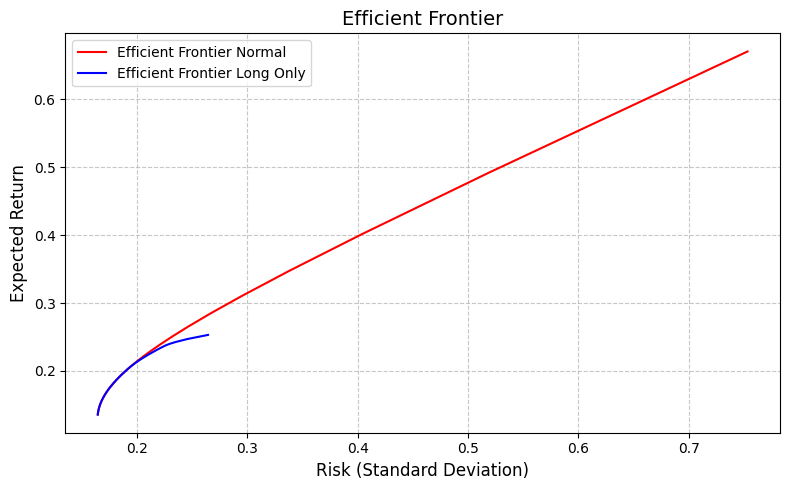

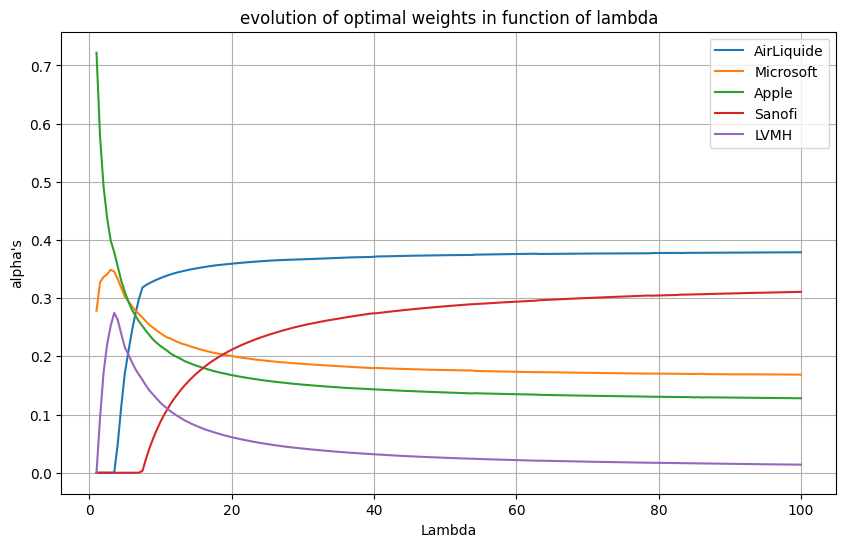

In [26]:
def solve_markowitz_longonly(mu, Sigma, lam, alpha0=None) -> np.ndarray:
    """
    solve_markowitz_longonly(mu: np.ndarray, Sigma: np.ndarray, target_return: float,
                             alpha0: np.ndarray=None)
    Long-only mean-variance portfolio optimization, i.e. mean-variance optimization with constraints of positive weightds.
    
    -------  Inputs ------------
    mu: (n,) expected returns (annualized)
    Sigma: (n,n) covariance (annualized)
    m: scalar (annualized) corresponding to the constraint \alpha\top mu = m
    alpha0: initial value of weights 

    -------- Output -----------
    optimal weights: d-dimensional vector (optimal alpha)
    """
    d = len(mu)
    if alpha0 is None:
        alpha0 = np.ones(d) / d  # start with an equally weighted portfolio
    
    def J(alpha):
        return - (alpha @ mu - lam / 2 * alpha.T @ Sigma @ alpha)
    
    bounds = [(0, 1) for _ in range(d)]
    cons = {'type': 'eq', 'fun': lambda alpha: np.sum(alpha) - 1}
    res = minimize(J, alpha0, method="SLSQP", bounds=bounds, constraints=cons)
    return res.x

def build_frontier_longonly(mu, Sigma, lambda_min=100, lambda_max=1000, n_points=200):
    """
    Build the efficient frontier.

    Returns:
        risks      : portfolio standard deviations
        returns    : portfolio expected returns
        weights    : list of optimal portfolios
        lambdas    : grid of lambda values
    """
    lambda_grid = np.linspace(lambda_min, lambda_max, n_points)
    risks = []
    returns = []
    alpha_res = []
    
    for lam in lambda_grid:
        alpha = solve_markowitz_longonly(mu, Sigma, lam)
        
        alpha_res.append(alpha)
        returns.append(alpha @ mu)
        risks.append(np.sqrt(alpha.T @ Sigma @ alpha))
        
    return np.array(risks), np.array(returns), alpha_res, lambda_grid

risks_lo, returns_lo, alpha_hat_lo, lambda_grid_lo = build_frontier_longonly(mu, Sigma, lambda_min=lambda_min, lambda_max=lambda_max, n_points=200)

plt.figure(figsize=(8, 5))
plt.plot(risks, returns, color="red", label="Efficient Frontier Normal")
plt.plot(risks_lo, returns_lo, color="blue", label="Efficient Frontier Long Only")
plt.title("Efficient Frontier", fontsize=14)
plt.xlabel("Risk (Standard Deviation)", fontsize=12)
plt.ylabel("Expected Return", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
alpha_mat = np.array(alpha_hat_lo)  # shape (200, 5) si tu as 5 actifs

plt.figure(figsize=(10,6))

# tracer chaque actif
n_assets = alpha_mat.shape[1]

for i in range(n_assets):
    plt.plot(lambda_grid, alpha_mat[:, i], label=f'{asset_names[i]}')

plt.xlabel("Lambda")
plt.ylabel("alpha's")
plt.title("evolution of optimal weights in function of lambda")
plt.legend()
plt.grid(True)
plt.show()

## 4. Markowitz on a rolling window


In this part, we propose to estimate the expected return and the covariance matrix on a rolling window, in order to observe their variation along time


Rolling mu shape: (2373, 5)


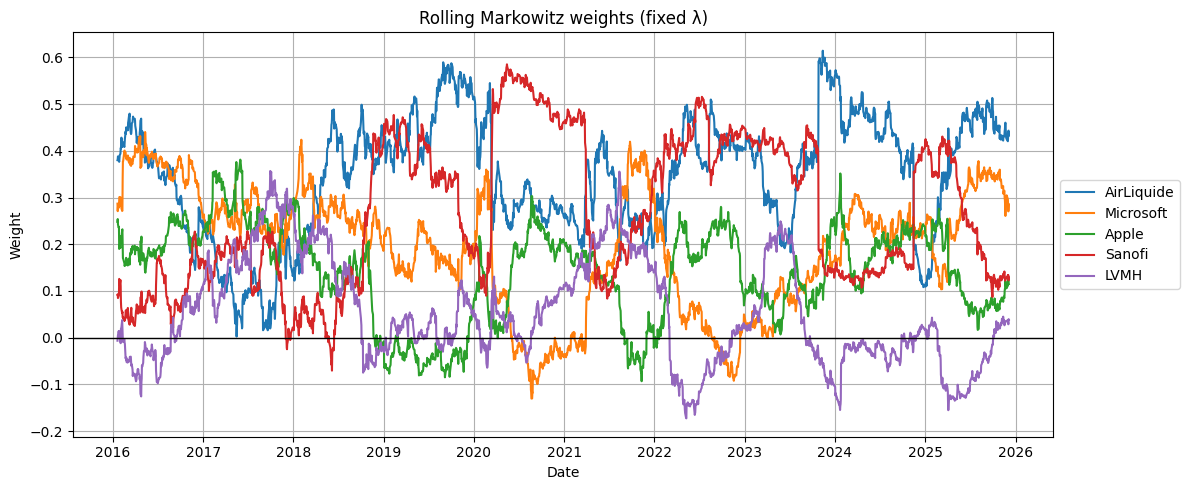

In [32]:

# %%
# ============================================================
# 4. Rolling estimation and dynamic Markowitz portfolios
# ============================================================
ret_daily = price.pct_change().dropna()

window = 252  # 1 year rolling window (daily data)
ann = 252.0

# Rolling estimates
mu_rolling = ret_daily.rolling(window).mean() * ann
Sigma_rolling = ret_daily.rolling(window).cov() * ann

print("Rolling mu shape:", mu_rolling.dropna().shape)


# %%
# Fixed risk aversion parameter
lam = 50.0

dates = mu_rolling.dropna().index
W_dyn = []
dates_used = []

for t in dates:
    mu_t = mu_rolling.loc[t].values
    Sigma_t = Sigma_rolling.loc[t].values
    try:
        w_t = solve_markowitz_lambda(mu_t, Sigma_t, lam)
        W_dyn.append(w_t)
        dates_used.append(t)
    except np.linalg.LinAlgError:
        continue

W_dyn = pd.DataFrame(W_dyn, index=dates_used, columns=price.columns)
W_dyn.head()


# %%
plt.figure(figsize=(12,5))
for asset in W_dyn.columns:
    plt.plot(W_dyn.index, W_dyn[asset], label=asset)
plt.axhline(0.0, color='black', lw=1)
plt.title("Rolling Markowitz weights (fixed λ)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()


## 4. Efficient frontier approximation with a Neural Network

We learn the mapping

$$
(\mu, \; \Sigma, \; \lambda) \; \mapsto \; \hat \alpha 
$$

where $\hat \alpha$ is the resulting optimal weights of the Markowitz problem with positivity constraint (long only position)
A simple MLP works well because the problem is *low dimensional* here. We use a **softmax output** to ensure weights are positive and sum to 1.

### 4.1 Dataset generation

In [33]:

from time import perf_counter



def build_hybrid_dataset(ret, solve_markowitz_longonly,
                         n_samples=20000,
                         window=252,
                         lam_range=(0.1,50),
                         noise_mu_scale=1.0,
                         noise_sigma_scale=0.05,
                         seed=0, verbose = True):

    rng = np.random.default_rng(seed)
    d = ret.shape[1]

    mu_roll = ret.rolling(window).mean().dropna() * 252
    Sigma_roll = ret.rolling(window).cov().dropna() * 252

    dates = mu_roll.index

    L = (d * (d + 1)) // 2
    input_dim = 1 + d + L
    X = np.zeros((n_samples, input_dim), dtype=np.float32)
    Y = np.zeros((n_samples, d), dtype=np.float32)

    for i in range(n_samples):

        # Pick random window
        t = rng.choice(dates)

        mu_t = mu_roll.loc[t].values
        Sigma_t = Sigma_roll.loc[t].values

        # Perturb mu
        std_mu = np.sqrt(np.diag(Sigma_t)/window)
        mu_sample = mu_t + noise_mu_scale * rng.normal(size=d) * std_mu

        # Perturb Sigma
        A = rng.normal(scale=noise_sigma_scale, size=(d,d))
        Sigma_sample = Sigma_t + A @ A.T
        Sigma_sample = 0.5*(Sigma_sample + Sigma_sample.T)  # resym

        # Random lambda
        lam = rng.uniform(*lam_range)

        # Label = Markowitz solution
        alpha_star = solve_markowitz_longonly(mu_sample, Sigma_sample, lam)

        # *** FIX CRITIQUE : un seul vecteur triangulaire ***
        Sigma_tril_vec = sigma_to_tril_vec(Sigma_sample)

        # Feature vector
        x = np.concatenate(([np.log(lam)], mu_sample, Sigma_tril_vec))

        X[i] = x
        Y[i] = alpha_star
        if verbose and (i+1) % max(1, n_samples // 10) == 0:
            print(f"{i+1}/{n_samples} done")

    return X, Y



def sigma_to_tril_vec(S: np.ndarray) -> np.ndarray:
    d = S.shape[0]
    i, j = np.tril_indices(d)
    return S[i, j]

def tril_vec_to_sigma(v: np.ndarray, d: int) -> np.ndarray:
    S = np.zeros((d, d), dtype=v.dtype)
    i, j = np.tril_indices(d)
    S[i, j] = v
    S[j, i] = v
    return S


In [35]:
d=len(mu)
n_samples = 1000
#lam=100
#X, y = build_dataset(d, n_samples, lambda_min=lambda_min, lambda_max=lambda_max, n_points=20)
X, y = build_hybrid_dataset(ret_daily, solve_markowitz_longonly,
                         n_samples=20000,
                         window=252,
                         lam_range=(lambda_min,lambda_max),
                         noise_mu_scale=1.0,
                         noise_sigma_scale=0.05)

2000/20000 done
4000/20000 done
6000/20000 done
8000/20000 done
10000/20000 done
12000/20000 done
14000/20000 done
16000/20000 done
18000/20000 done
20000/20000 done


In [36]:
def data_split(X, y, train_frac=0.7, val_frac=0.15):
    """
    Randomly Split dataset (X,y) in (X_train, y_train), (X_val, y_val), (X_test, y_test)
    if permutation = False, the split is temporal
    Inputs
    ----------
    X : np.ndarray, shape (n_samples, d)
    y : np.ndarray, shape (n_samples, 1)
    train_frac : float, fraction for X_train size (default value 0.7)
    val_frac   : float, fraction for X_ val size (default value 0.15)

    Output
    ------
    (X_train, y_train), (X_val, y_val), (X_test, y_test)

    """

    # Lengths    
    n = X.shape[0]   
    ny = y.shape[0]
    # Check of equal number of samples
    if n != ny:
        raise ValueError(f"X and y must have the same number of samples (X:{n}, y:{ny})")

    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    
    # Random permutation of the samples
    idx = np.random.permutation(n)
    
    # Split indices
    idx_train = idx[:n_train]
    idx_val   = idx[n_train:n_train + n_val]
    idx_test  = idx[n_train + n_val:]


    # Split Data
    X_train, y_train = X[idx_train], y[idx_train]
    X_val,   y_val   = X[idx_val],   y[idx_val]
    X_test,  y_test  = X[idx_test],  y[idx_test]
        
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


(X_train, y_train), (X_val, y_val), (X_test, y_test) = data_split(X, y, 0.5, 0.1)
list(map(len, [X_train, X_val, X_test]))

from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)


#scaler_y = StandardScaler().fit(y_train) 
y_train_s = y_train
y_val_s   = y_val
y_test_s  = y_test

# Transform Dataset in Torch objects
train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                         torch.tensor(y_train_s,   dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(X_val_s,   dtype=torch.float32),
                         torch.tensor(y_val_s,     dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(X_test_s,  dtype=torch.float32),
                         torch.tensor(y_test_s,    dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)  # Shuffle => mix or not the data. False => keep time order of the data
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# Sanity check
print("X_train mean (approx):", X_train_s.mean(axis=0))
print("X_train std  (approx):", X_train_s.std(axis=0))

X_train mean (approx): [ 7.3957445e-08 -3.4254043e-08  3.4701824e-08 -3.5049020e-08
 -7.2360038e-09 -8.7618828e-09  6.8944694e-08  1.5801191e-08
 -3.6358833e-10  2.4718046e-08 -3.1012295e-08  3.0159950e-09
 -5.3885579e-08  2.5391579e-08 -1.7517806e-08  5.0413608e-08
 -7.6216459e-08  3.7443638e-08  4.1043759e-08 -1.6671420e-08
 -1.2060850e-07]
X_train std  (approx): [0.9999983  0.99999976 0.9999992  0.9999999  0.99999976 1.0000014
 1.0000006  1.0000006  1.0000002  0.99999976 0.99999946 1.
 0.9999985  0.99999934 0.99999994 0.9999989  0.999999   1.0000001
 0.9999987  1.0000007  1.0000001 ]


Epoch 020 | Train MSE=0.008558 | Val MSE=0.010251
Epoch 040 | Train MSE=0.004895 | Val MSE=0.008170
Epoch 060 | Train MSE=0.003459 | Val MSE=0.006647
Epoch 080 | Train MSE=0.002992 | Val MSE=0.006440
Epoch 100 | Train MSE=0.002985 | Val MSE=0.006743
Epoch 120 | Train MSE=0.002032 | Val MSE=0.005339
Epoch 140 | Train MSE=0.001556 | Val MSE=0.005824
Early stopping.


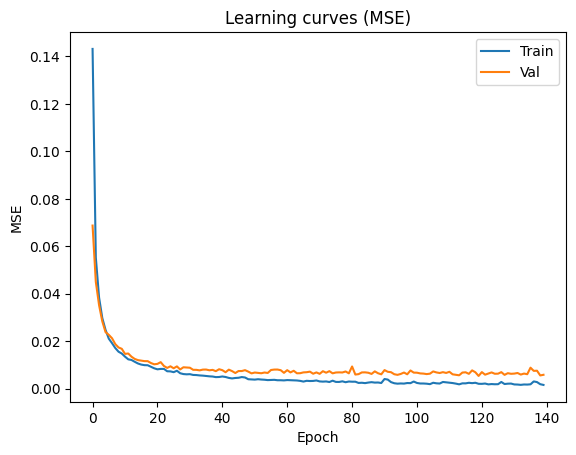

In [37]:
# Training with early stopping on validation RMSE
import math
best_val = math.inf
patience= 20
EPOCHS = 250
file_save_best_model = "fast_pricing_mlp.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
class MLP(nn.Module):
    def __init__(self, in_dim,out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,out_dim)
        )
    def forward(self, x):
        logits = self.net(x)
        tau = 2.0 # temperature coef
        alpha = torch.softmax(logits / tau, dim=1)
        return alpha


model = MLP(in_dim=X_train_s.shape[1], out_dim = y_train_s.shape[1]).to(device)

#criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def run_epoch(loader, train=False):
    if train: model.train()
    else: model.eval()
    losses = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        eps = 1e-8
        pred   = torch.clamp(pred, eps, 1.0)
        target = torch.clamp(yb,  eps, 1.0)

        loss = torch.sum(target * (torch.log(target) - torch.log(pred)), dim=1).mean()

        #loss = criterion(pred, yb)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)


patience_cnt = 0
train_data, val_data = [], []
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(train_loader, train=True) # Can mix the order since we are not working with time series
    va = run_epoch(val_loader,   train=False) # Must keep the order to match with predicted value
    train_data.append(tr); val_data.append(va)
    val_mse = va
    if val_mse < best_val - 1e-6:
        best_val = val_mse
        patience_cnt = 0
        torch.save(model.state_dict(), file_save_best_model)
    else:
        patience_cnt += 1
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train MSE={tr:.6f} | Val MSE={val_mse:.6f}")
    if patience_cnt >= patience:
        print("Early stopping.")
        break

plt.figure()
plt.plot(train_data)
plt.plot(val_data)
plt.title("Learning curves (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend(["Train","Val"])
plt.show()

            AirLiquide  Microsoft     Apple    Sanofi      LVMH
AirLiquide    0.040839   0.016837  0.015925  0.020010  0.033030
Microsoft     0.016837   0.072837  0.052005  0.008045  0.024646
Apple         0.015925   0.052005  0.083357  0.008033  0.025693
Sanofi        0.020010   0.008045  0.008033  0.050869  0.021461
LVMH          0.033030   0.024646  0.025693  0.021461  0.081802
[[0.0408389  0.01683657 0.0159253  0.02001048 0.0330302 ]
 [0.01683657 0.07283703 0.05200464 0.00804536 0.0246459 ]
 [0.0159253  0.05200464 0.08335653 0.0080326  0.02569263]
 [0.02001048 0.00804536 0.0080326  0.05086878 0.02146083]
 [0.0330302  0.0246459  0.02569263 0.02146083 0.08180235]]


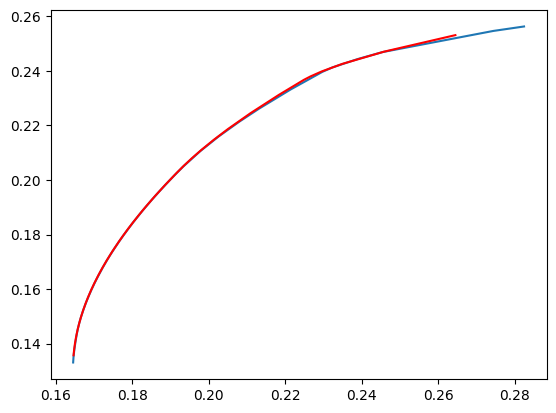

In [38]:
# Load the best model (saved during learning)
model.load_state_dict(torch.load(file_save_best_model, map_location=device))
model.eval()

# Test efficient curve
print(Sigma)
Sigma_np = Sigma.values if hasattr(Sigma, "values") else Sigma
print(Sigma_np)
risks_lo, returns_lo, alpha_hat_lo, lambda_grid_lo = build_frontier_longonly(mu, Sigma_np, lambda_min=lambda_min, lambda_max=lambda_max, n_points=200)


#lambda_grid = np.linspace(lambda_min, lambda_max, 200)
X_nn = []
#lambda_grid = np.linspace(lambda_min, lambda_max, 200)

for lam in lambda_grid_lo:
    #x = np.concatenate([mu, sigma_to_tril_vec(Sigma_np),[lam]])
    Sigma_tril_vec = sigma_to_tril_vec(Sigma_np)  # type: ignore
    x = np.concatenate(([np.log(lam)], mu, Sigma_tril_vec))
    X_nn.append(x)


X_nn = np.array(X_nn, dtype=np.float32)

X_nn_scaled = scaler_X.transform(X_nn)

X_nn_torch = torch.tensor(X_nn_scaled).to(device)

#model.eval()
with torch.no_grad():
    alpha_nn = model(X_nn_torch).cpu().numpy()


risks_nn = []
returns_nn = []

for i in range(len(lambda_grid_lo)):

    w = alpha_nn[i]

    ret = w @ mu
    risk = np.sqrt(w @ Sigma @ w)

    risks_nn.append(risk)
    returns_nn.append(ret)

plt.figure()
plt.plot(risks_nn, returns_nn)
plt.plot(risks_lo, returns_lo, color='r')
plt.show()

## 5. Using the NN as a fast allocator (mini backtest)

We now pick a target return (for instance the one maximizing the Sharpe ratio on the estimated frontier) and compare: 

- Buy-and-hold of the chosen Markowitz weights,
- Buy-and-hold of the NN weights,
- Equal-weight benchmark.

This is **not** a production-grade backtest (no rolling estimation), but a quick illustration.

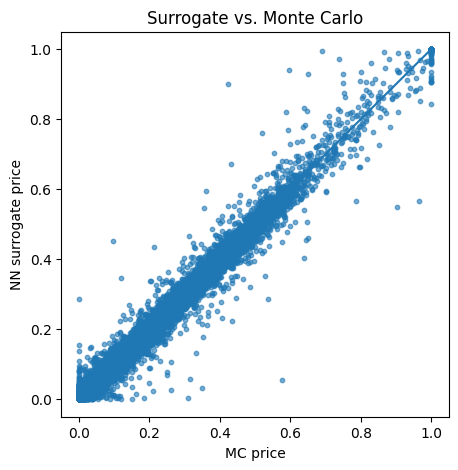

In [39]:
# Also import the scaling parameters
          
# Prediction on the test set
with torch.no_grad():
    y_test_pred = []
    for xb, _ in test_loader:
        xb = xb.to(device)
        y_test_pred.append(model(xb).cpu().numpy())
    y_test_pred = np.concatenate(y_test_pred, axis=0)

# Unscale
y_test_hat = y_test_pred
# MAE and RMSE

# Scatterplot MC vs. NN
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_test_hat, s=10, alpha=0.6)
m = float(min(y_test.min(), y_test_hat.min()))
M = float(max(y_test.max(), y_test_hat.max()))
plt.plot([m, M], [m, M])
plt.xlabel("MC price")
plt.ylabel("NN surrogate price")
plt.title("Surrogate vs. Monte Carlo")
plt.show()

Rolling mu shape: (2373, 5)


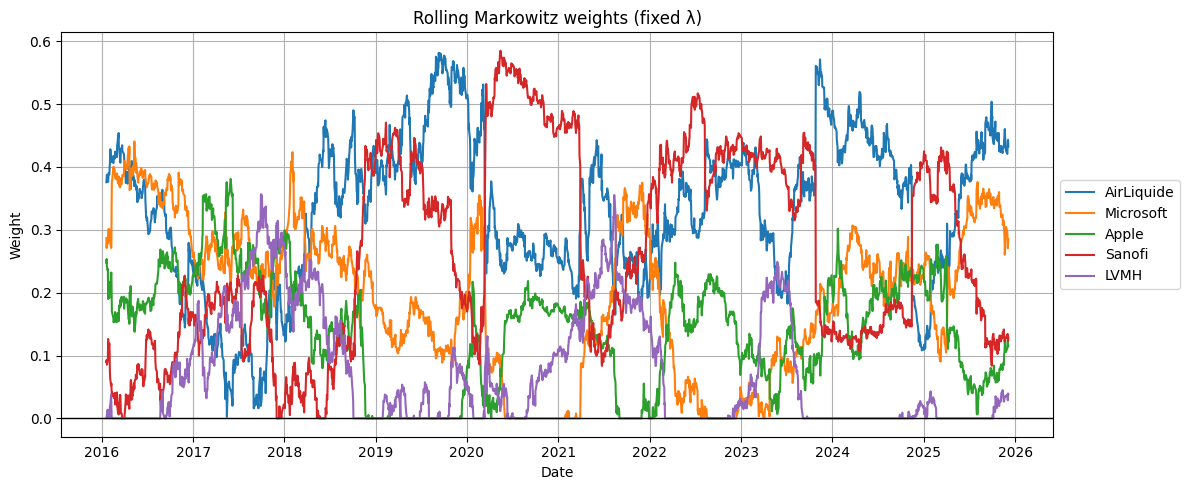

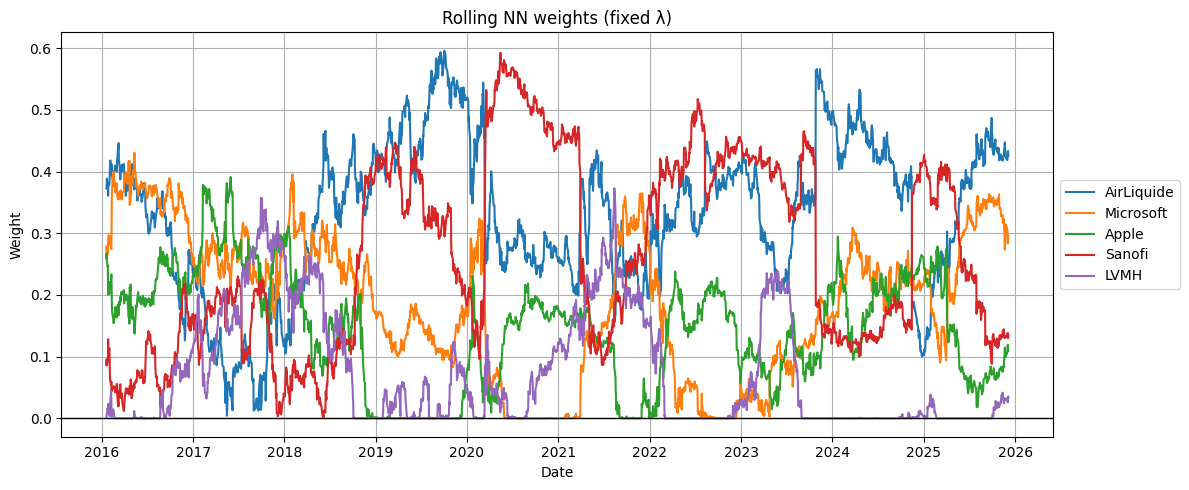

In [40]:
# %%
# ============================================================
# Rolling estimation with NN predictions
# ============================================================
ret_daily = price.pct_change().dropna()
window = 252  # 1 year rolling window (daily data)
ann = 252.0

# Rolling estimates
mu_rolling = ret_daily.rolling(window).mean() * ann
Sigma_rolling = ret_daily.rolling(window).cov() * ann

print("Rolling mu shape:", mu_rolling.dropna().shape)


# %%
# Fixed risk aversion parameter
lam = 50.0


dates = mu_rolling.dropna().index
W_dyn = []
dates_used = []
W_nn = []
for t in dates:
    mu_t = mu_rolling.loc[t].values
    Sigma_t = Sigma_rolling.loc[t].values
    try:
        w_t = solve_markowitz_longonly(mu_t, Sigma_t, lam)
        W_dyn.append(w_t)
        dates_used.append(t)
    except np.linalg.LinAlgError:
        continue
    #Sigma_np = Sigma_t.values if hasattr(Sigma, "values") else Sigma_t
    

    Sigma_tril_vec = sigma_to_tril_vec(Sigma_t)
    x_t = np.concatenate(([np.log(lam)], mu_t, Sigma_tril_vec))
    #x_t = np.concatenate([mu_t, sigma_to_tril_vec(Sigma_t), [lam]])


    X_nn = np.array(x_t, dtype=np.float32).reshape(1, -1)
    X_nn_scaled = scaler_X.transform(X_nn)
   
    X_nn_torch = torch.tensor(X_nn_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        alpha_nn = model(X_nn_torch).cpu().numpy().flatten()
    W_nn.append(alpha_nn)
W_dyn = pd.DataFrame(W_dyn, index=dates_used, columns=price.columns)
W_dyn.head()


# %%
plt.figure(figsize=(12,5))
for asset in W_dyn.columns:
    plt.plot(W_dyn.index, W_dyn[asset], label=asset)
plt.axhline(0.0, color='black', lw=1)
plt.title("Rolling Markowitz weights (fixed λ)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()

W_nn = pd.DataFrame(W_nn, index=dates_used, columns=price.columns)
plt.figure(figsize=(12,5))
for asset in W_nn.columns:
    plt.plot(W_nn.index, W_nn[asset], label=asset)
plt.axhline(0.0, color='black', lw=1)
plt.title("Rolling NN weights (fixed λ)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.grid(True)
plt.tight_layout()


In [41]:
# -----------------------------
# MARKOWITZ TIMING
# -----------------------------
import time
start_mkv = time.perf_counter()

W_dyn = []
dates_used = []

for t in dates:
    mu_t = mu_rolling.loc[t].values
    Sigma_t = Sigma_rolling.loc[t].values
    try:
        w_t = solve_markowitz_longonly(mu_t, Sigma_t, lam)
        W_dyn.append(w_t)
        dates_used.append(t)
    except np.linalg.LinAlgError:
        continue

end_mkv = time.perf_counter()
time_mkv = end_mkv - start_mkv


# -----------------------------
# NN TIMING
# -----------------------------
start_nn = time.perf_counter()

W_nn = []

for t in dates_used:
    mu_t = mu_rolling.loc[t].values
    Sigma_t = Sigma_rolling.loc[t].values

    Sigma_tril_vec = sigma_to_tril_vec(Sigma_t)
    x_t = np.concatenate(([np.log(lam)], mu_t, Sigma_tril_vec))

    X_nn = np.array(x_t, dtype=np.float32).reshape(1, -1)
    X_nn_scaled = scaler_X.transform(X_nn)

    X_nn_torch = torch.tensor(X_nn_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        alpha_nn = model(X_nn_torch).cpu().numpy().flatten()

    W_nn.append(alpha_nn)

end_nn = time.perf_counter()
time_nn = end_nn - start_nn


# -----------------------------
# Results
# -----------------------------
n = len(dates_used)

print("Number of rebalancing dates:", n)
print("Total Markowitz time   : {:.4f} sec".format(time_mkv))
print("Total NN time          : {:.4f} sec".format(time_nn))
print("Time per date Markowitz: {:.6f} sec".format(time_mkv / n))
print("Time per date NN       : {:.6f} sec".format(time_nn / n))
print("Speed-up factor        : {:.1f}x".format(time_mkv / time_nn))

Number of rebalancing dates: 2373
Total Markowitz time   : 11.7641 sec
Total NN time          : 2.7848 sec
Time per date Markowitz: 0.004957 sec
Time per date NN       : 0.001174 sec
Speed-up factor        : 4.2x
